In [51]:
import pandas as pd
import datetime
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib import rcParams
plt.rcParams['text.usetex'] = True
plt.rcParams['text.latex.preamble'] = r'\usepackage{lmodern}'  # Usar Latin Modern Roman
rcParams['font.family'] = 'serif'
rcParams['font.serif'] = ['Latin Modern Roman']
import numpy as np
from tensorflow import keras
#sns.set_style('dark')
plt.rcParams['font.size'] = 16
import json
import os
import copy
from IPython.display import display, HTML

# from sklearn.metrics import mean_squared_error
# from sklearn.metrics import r2_score

import scipy as sp
from scipy.optimize import curve_fit

import uproot
import awkward as ak

import awkward as ak
import matplotlib.pyplot as plt
import hist
import math
import numpy as np
import vector
import pylhe
import seaborn as sns
from matplotlib import colormaps

In [52]:
os.getcwd()

'/Users/esser/Documents/PROJECTS/ALPsPheno/ALP GLOBAL/github/ALP_Global/notebooks'

# Signal events for 0l

## Read in the signal

In [53]:
fileg = "../MadGraph/ppZZjj0l/Events/run_01/unweighted_events.lhe"
events = pylhe.to_awkward(pylhe.read_lhe_with_attributes(fileg))

Identify the particles

In [54]:
j1=events.particles.vector[:,-2]
j2=events.particles.vector[:,-1]
Z1=events.particles.vector[:,2]
Z2=events.particles.vector[:,3]
lp=events.particles.vector[:,-5]
lm=events.particles.vector[:,-6]
nu3=events.particles.vector[:,-4]
nu4=events.particles.vector[:,-3]

In [64]:
mZZ = (Z1+Z2).mass

Function to read in the total cross section and total number of events from the lhe file. Note that for different processes the rows may shift.

In [55]:
def read_sigma_nevents(filename):
    with open(filename,'r') as f:
        data = f.readlines()
    f.close()
    sigma = float(data[439].split(' ')[13])
    nevents = float(data[151].split(' ')[2])
    return sigma, nevents

In [56]:
(sigma, Ntot) = read_sigma_nevents(fileg)

In [57]:
sigma

0.00030668968546183

In [58]:
Ntot

100000.0

## Data Visualisation!

Here, we interpret the charged leptons as jets.

delta R separation between the charged leptons

In [59]:
min(lp.deltaR(lm))

0.054610694590264505

In [40]:
max(lp.deltaR(lm))

5.516634236122154

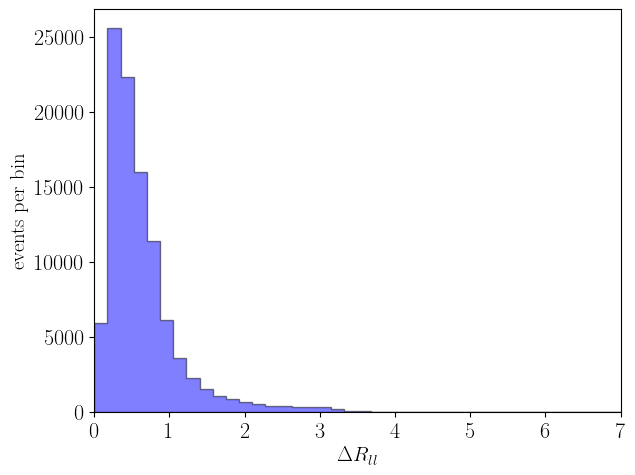

In [60]:
# histogram for NP signal (n = number of events per bin)
# density=True gives bin's raw count divided by the total number of counts and the bin width, i.e. density = counts / (sum(counts) * np.diff(bins)
n_dR, bins_dR, _ =plt.hist(lp.deltaR(lm),bins=40,range=(0,7),label='non-linear axion', alpha=0.5,density=False,color = "blue", ec="k",histtype='stepfilled',log=False)
plt.xlim(0, 7)
plt.tight_layout()
plt.xlabel(r'$\Delta R_{ll}$ ',fontsize=15)
plt.ylabel(r'events per bin',fontsize=15)
#plt.savefig("mgammagamma.pdf")
plt.show()

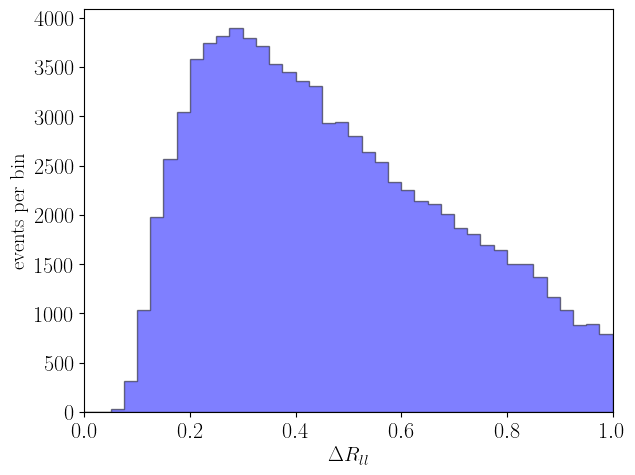

In [61]:
# histogram for NP signal (n = number of events per bin)
# density=True gives bin's raw count divided by the total number of counts and the bin width, i.e. density = counts / (sum(counts) * np.diff(bins)
n_dR, bins_dR, _ =plt.hist(lp.deltaR(lm),bins=40,range=(0,1),label='non-linear axion', alpha=0.5,density=False,color = "blue", ec="k",histtype='stepfilled',log=False)
plt.xlim(0, 1)
plt.tight_layout()
plt.xlabel(r'$\Delta R_{ll}$ ',fontsize=15)
plt.ylabel(r'events per bin',fontsize=15)
#plt.savefig("mgammagamma.pdf")
plt.show()

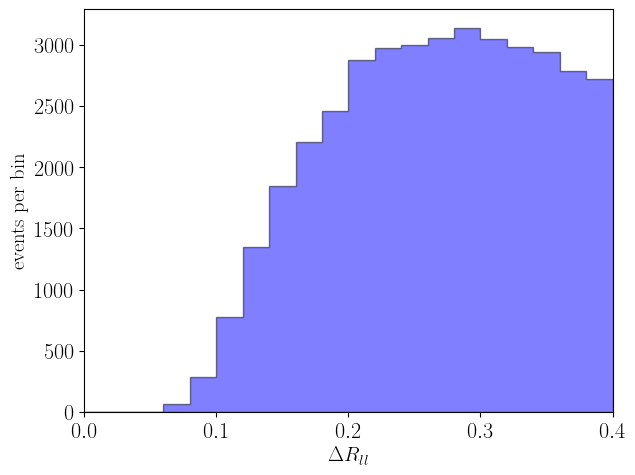

In [62]:
n_J, bins_J, _ =plt.hist(lp.deltaR(lm),bins=20,range=(0,0.4),label='non-linear axion', alpha=0.5,density=False,color = "blue", ec="k",histtype='stepfilled',log=False)
plt.xlim(0, 0.4)
plt.tight_layout()
plt.xlabel(r'$\Delta R_{ll}$ ',fontsize=15)
plt.ylabel(r'events per bin',fontsize=15)
#plt.savefig("mgammagamma.pdf")
plt.show()

In [63]:
# fraction of the events that results in the fat jet topology
n_J.sum()/Ntot

0.38497

In [65]:
# resolved region
mZZ_res = [mZZ[i] for i in range(len(events)) if (lp.deltaR(lm))[i] > 0.4];

In [128]:
# fat jet region
mZZ_fat = [mZZ[i] for i in range(len(events)) if (lp.deltaR(lm))[i] < 0.4];

# Invariant mass of the ZZ $m_{\nu\nu jj}$ in the resolved region

In [269]:
mZZ_bins = (0,200,400,600,800,1000,1200,1400,1600);

In [270]:
mZZ_bin_center = (100,300,500,700,900,1100,1300,1500);

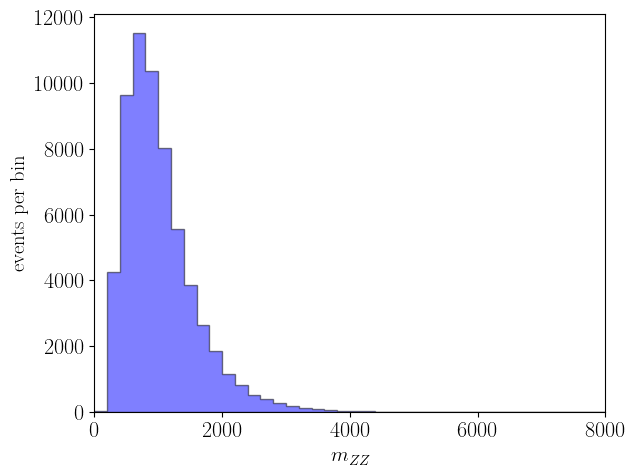

In [271]:
# in arbitrary bins
n, bins, _ =plt.hist(mZZ_res,bins=40,range=(0,8000),label='non-linear axion', alpha=0.5,density=False,color = "blue", ec="k",histtype='stepfilled',log=False)
plt.xlim(0, 8000)
plt.tight_layout()
plt.xlabel(r'$m_{ZZ}$ ',fontsize=15)
plt.ylabel(r'events per bin',fontsize=15)
#plt.savefig("mgammagamma.pdf")
plt.show()

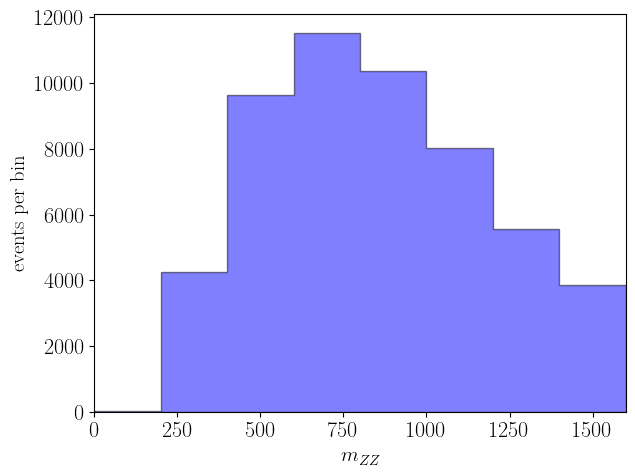

In [272]:
# in ATLAS bins
n, bins, _ =plt.hist(mZZ_res,bins=mZZ_bins,range=(0,1600),label='non-linear axion', alpha=0.5,density=False,color = "blue", ec="k",histtype='stepfilled',log=False)
plt.xlim(0, 1600)
plt.tight_layout()
plt.xlabel(r'$m_{ZZ}$ ',fontsize=15)
plt.ylabel(r'events per bin',fontsize=15)
#plt.savefig("mgammagamma.pdf")
plt.show()

In [273]:
# calculate the efficiency as the number of events that fall into the bins
eps = n.sum()/Ntot

In [274]:
eps

0.53236

## Read in the digitised data and background from Figure 10a in the auxiliary material

In [275]:
#background 
background = pd.read_csv('../MadGraph/ppZZjj0l/0leptonBG.csv', sep=';', nrows=8, header=0).values[:,1]

In [276]:
data_by_BG = pd.read_csv('../MadGraph/ppZZjj0l/0leptonData_BG_point.csv', sep=';', nrows=7, header=0).values[:,1]

In [277]:
data_by_BG

array([0.9666748 , 0.99468665, 1.01990703, 1.08072986, 1.13099893,
       0.93158645, 1.04889832])

In [278]:
unc_upper_by_BG = pd.read_csv('../MadGraph/ppZZjj0l/0leptonData_BG_upper.csv', sep=';', nrows=7, header=0).values[:,1]

In [279]:
unc_lower_by_BG = pd.read_csv('../MadGraph/ppZZjj0l/0leptonData_BG_lower.csv', sep=';', nrows=7, header=0).values[:,1]

In [280]:
data = np.multiply(data_by_BG, background[:-1])
unc_upper = np.multiply(unc_upper_by_BG, background[:-1])
unc_lower = np.multiply(unc_lower_by_BG, background[:-1])

In [281]:
data[6]= 12.746705111225948

In [282]:
data=np.append(data, 3.977818410667322)
unc_upper=np.append(unc_upper, 7.016334515745862)
unc_lower=np.append(unc_lower, 2.129249327519135)

In [283]:
data

array([1.88100056e+03, 1.33515748e+04, 5.78012462e+03, 9.99332689e+02,
       1.99475189e+02, 3.71123785e+01, 1.27467051e+01, 3.97781841e+00])

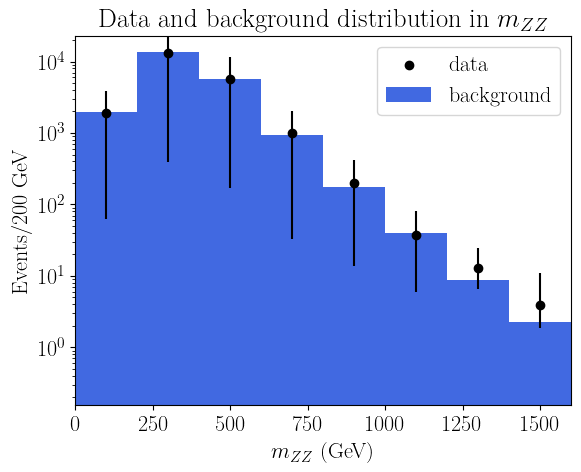

In [284]:
plt.bar(mZZ_bins[:-1], background, width=np.diff(mZZ_bins), align='edge', alpha=1, color='royalblue',label='background')
plt.scatter(mZZ_bin_center, data, color='black', label='data')
plt.xlim(0,1600)
#plt.ylim(0,5)
plt.yscale("log")
plt.errorbar(mZZ_bin_center, data, [unc_lower, unc_upper], color='black', alpha=1,fmt='none')
plt.xlabel('$m_{ZZ}$ (GeV) ')
plt.ylabel(r'Events/200 GeV')
plt.title("Data and background distribution in $m_{ZZ}$")
plt.legend()

In [285]:
(data*np.diff(mZZ_bins)).sum()

4453068.9431023

## Signal events in the right bins, normalised distribution 

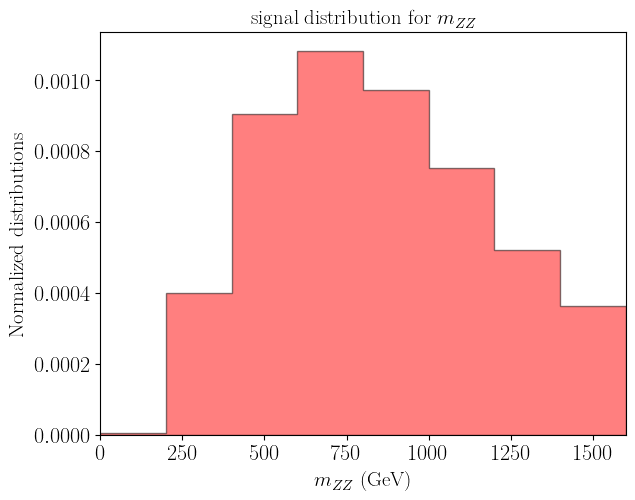

In [286]:
# histogram for NP signal (n = number of events per bin)
# density=True gives bin's raw count divided by the total number of counts and the bin width, i.e. density = counts / (sum(counts) * np.diff(bins))
n_signal, bins, _ = plt.hist(mZZ_res,bins=mZZ_bins,range=(0,2000),label='non-linear axion', alpha=0.5,density=True,color = "red", ec="k",histtype='stepfilled',log=False)
plt.xlim(0, 1600)
#plt.yscale("log")
plt.tight_layout()
plt.title(r'signal distribution for $m_{ZZ}$ ',fontsize=15)
plt.xlabel(r'$m_{ZZ}$ (GeV)',fontsize=15)
plt.ylabel(r'Normalized distributions',fontsize=15)
#plt.savefig("mHHdist.pdf")
plt.show()

In [287]:
(n_signal*np.diff(mZZ_bins)).sum()

1.0

ATLAS also gives the data and background in events per bin and per bin width, meaning that we do not have to multiply with the bin width to compare the signal.

## Compare signal with data and background


In [288]:
# BR: factor of the branching ratios due to generating Z-> nu nu instead of Z-> jj
BR_Znunu = 0.2
BR_Zll = 0.101
BR_Zjj = 0.699

BR = BR_Zjj/BR_Zll

In [289]:
# rescale the MG5 signal events to compare with the data: N_events = n_signal * lumi * sigma * eps * BR
# eps = efficiency to the bin selection = number of events that fall in the ATLAS bins/ number of all events
# sigma in lhe file: total cross section including BR sigma in pb


# careful! the lumi is given in fb^-1 but the cross section from MadGraphin pb, which explains the additional factor of 1000.
lumi = 140

N_events = n_signal*lumi*sigma*1000*eps*BR

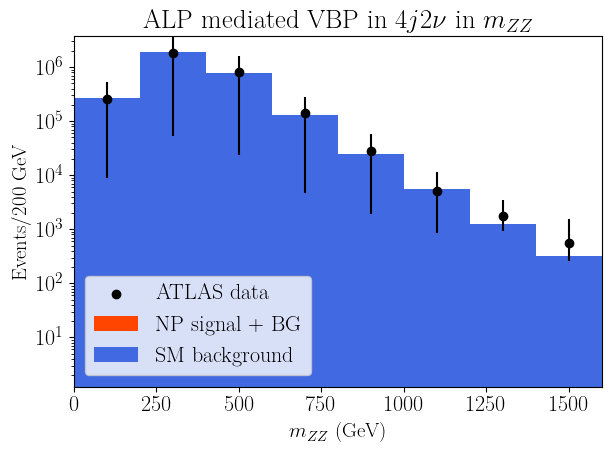

In [290]:
plt.bar(mZZ_bins[:-1], background*lumi+N_events, width=np.diff(mZZ_bins), align='edge', alpha=1, color='orangered', label='NP signal + BG')
plt.bar(mZZ_bins[:-1], background*lumi, width=np.diff(bins), align='edge', alpha=1, color='royalblue',label='SM background')
plt.xlim(0, 1600)
#plt.ylim(0,10000)
plt.yscale("log")
plt.xlabel('$m_{ZZ}$ (GeV)',fontsize=15)
plt.ylabel(r'Events/200 GeV', fontsize=15)
plt.errorbar(mZZ_bin_center, data*lumi, yerr=[unc_lower*lumi, unc_upper*lumi], color='black', alpha=1,fmt='none')
plt.scatter(mZZ_bin_center, data*lumi, color='black', label='ATLAS data')
plt.legend(loc=3)
plt.title(r" ALP mediated VBP in $4j2\nu$ in $m_{ZZ}$")
plt.tight_layout()
plt.savefig("/Users/esser/Documents/PROJECTS/ALPsPheno/ALP GLOBAL/github/ALP_GLOBAL/Figures/ZZjj0l_res.pdf")
plt.show()

### Output data to Mathematica

In [120]:
# calculate the mean error from the upper and lower end
data_unc = (unc_upper-unc_lower)/2

In [121]:
# data
Mathematica_data = "{" + ",".join([f"{x:.4e}".replace('e', '*10^') for x in data]) + "}" + ";"
print(Mathematica_data)

{1.8810*10^+03,1.3352*10^+04,5.7801*10^+03,9.9933*10^+02,1.9948*10^+02,3.7112*10^+01,1.2747*10^+01,3.9778*10^+00};


In [122]:
# data unc
Mathematica_data_unc = "{" + ",".join([f"{x:.4e}".replace('e', '*10^') for x in data_unc]) + "}" ";"
print(Mathematica_data_unc)

{5.6269*10^+01,3.8306*10^+02,1.6097*10^+02,3.3464*10^+01,1.4171*10^+01,6.6263*10^+00,2.8446*10^+00,2.4435*10^+00};


In [123]:
# background
Mathematica_background = "{" + ",".join([f"{x:.4e}".replace('e', '*10^') for x in background]) + "}" ";"
print(Mathematica_background)

{1.9458*10^+03,1.3423*10^+04,5.6673*10^+03,9.2468*10^+02,1.7637*10^+02,3.9838*10^+01,8.8044*10^+00,2.2490*10^+00};


In [124]:
# signal
N_signal = n_signal * lumi * sigma * 1000 * eps * BR
Mathematica_signal = "{" + ",".join([f"{x:.4e}".replace('e', '*10^') for x in N_signal]) + "}" ";"
print(Mathematica_signal)

{6.9831*10^-04,6.3235*10^-02,1.4307*10^-01,1.7127*10^-01,1.5375*10^-01,1.1901*10^-01,8.2475*10^-02,5.7470*10^-02};


In [126]:
# bin center
Mathematica_bin_center = "{" + ",".join(["{:.0f}".format(x) for x in mZZ_bin_center]) + "}" ";"
print(Mathematica_bin_center)

{100,300,500,700,900,1100,1300,1500};


# Invariant mass of the ZZ $m_{\nu\nu J}$ in the merged region

In [187]:
mZZ_bins_fat = (0,200,400,600,800,1000,1200,1400,1600);

In [188]:
mZZ_bin_center_fat = (100,300,500,700,900,1100,1300,1500);

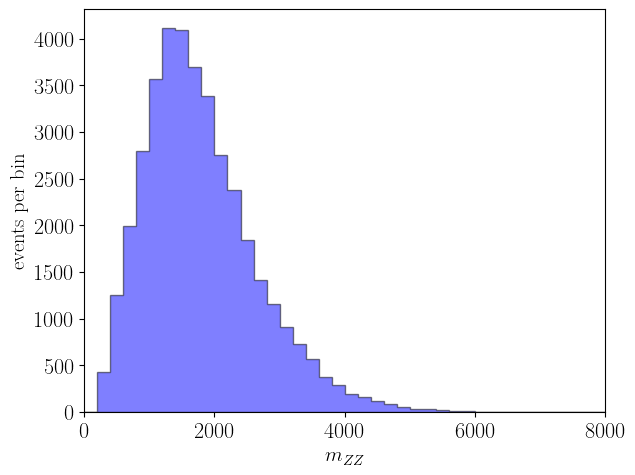

In [138]:
# in arbitrary bins
n, bins, _ =plt.hist(mZZ_fat,bins=40,range=(0,8000),label='non-linear axion', alpha=0.5,density=False,color = "blue", ec="k",histtype='stepfilled',log=False)
plt.xlim(0, 8000)
plt.tight_layout()
plt.xlabel(r'$m_{ZZ}$ ',fontsize=15)
plt.ylabel(r'events per bin',fontsize=15)
#plt.savefig("mgammagamma.pdf")
plt.show()

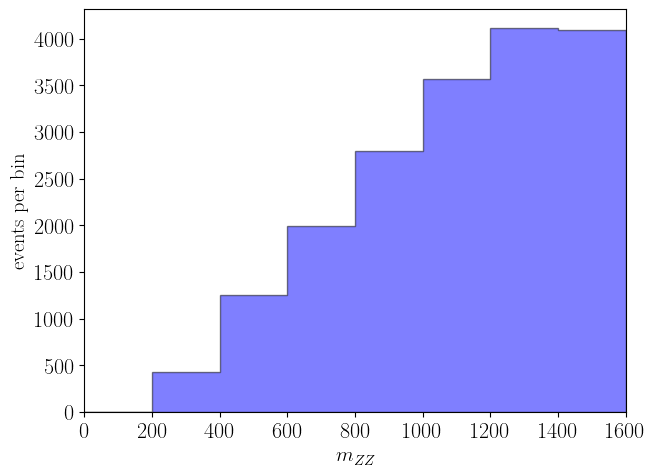

In [189]:
# in ATLAS bins
n, bins, _ =plt.hist(mZZ_fat,bins=mZZ_bins_fat,range=(0,1600),label='non-linear axion', alpha=0.5,density=False,color = "blue", ec="k",histtype='stepfilled',log=False)
plt.xlim(0, 1600)
plt.tight_layout()
plt.xlabel(r'$m_{ZZ}$ ',fontsize=15)
plt.ylabel(r'events per bin',fontsize=15)
#plt.savefig("mgammagamma.pdf")
plt.show()

In [190]:
# calculate the efficiency as the number of events that fall into the bins
eps_fat = n.sum()/Ntot

In [191]:
eps_fat

0.18249

## Read in the digitised data and background from Figure 10c in the auxiliary material

In [192]:
len(mZZ_bins_fat)

9

In [224]:
#background for all 8 bins
background_fat = pd.read_csv('../MadGraph/ppZZjj0l/0leptonBG_mergedHP.csv', sep=';', nrows=8, header=0).values[:,1]

In [225]:
len(background_fat)

8

In [226]:
# data by background from lower plot, only first 5 bins
data_by_BG_fat = pd.read_csv('../MadGraph/ppZZjj0l/0leptonData_BGpoint_mergedHP.csv', sep=';', nrows=5, header=0).values[:,1]

In [227]:
len(data_by_BG_fat)

5

In [228]:
data_by_BG_fat

array([1.18058047, 0.94603576, 1.02993793, 0.81363282, 0.8927594 ])

In [229]:
# uncertainty by BG, only first 5 bins
unc_upper_by_BG_fat = pd.read_csv('../MadGraph/ppZZjj0l/0leptonData_BGupper_mergedHP.csv', sep=';', nrows=8, header=0).values[:,1]

In [230]:
# uncertainty by BG, only first 5 bins
unc_lower_by_BG_fat = pd.read_csv('../MadGraph/ppZZjj0l/0leptonData_BGlower_mergedHP.csv', sep=';', nrows=7, header=0).values[:,1]

In [231]:
len(unc_upper_by_BG_fat)

5

In [232]:
len(unc_lower_by_BG_fat)

5

In [233]:
# last two bins, directly data and uncertainy, not normalised by BG
data_last2bins_fat = pd.read_csv('../MadGraph/ppZZjj0l/0leptonlast2Datapoint_mergedHP.csv', sep=';', nrows=2, header=0).values[:,1]

In [234]:
unc_upper_last2bins_fat = pd.read_csv('../MadGraph/ppZZjj0l/0leptonlast2Dataupper_mergedHP.csv', sep=';', nrows=2, header=0).values[:,1]

In [235]:
unc_lower_last2bins_fat = pd.read_csv('../MadGraph/ppZZjj0l/0leptonlast2Datalower_mergedHP.csv', sep=';', nrows=2, header=0).values[:,1]

In [241]:
# add the 3rd last bin by hand
data_last3bins_fat = np.append(20.114162087974147, data_last2bins_fat)

In [242]:
unc_upper_last3bins_fat = np.append(27.522552951783258, unc_upper_last2bins_fat)

In [243]:
unc_lower_last3bins_fat = np.append(16.814382932144426, unc_lower_last2bins_fat)

In [244]:
data_5bins_fat = np.multiply(data_by_BG_fat, background_fat[:-3])
unc_upper_5bins_fat = np.multiply(unc_upper_by_BG_fat, background_fat[:-3])
unc_lower_5bins_fat = np.multiply(unc_lower_by_BG_fat, background_fat[:-3])

In [245]:
data_fat = np.append(data_5bins_fat, data_last3bins_fat)
unc_upper_fat = np.append(unc_upper_5bins_fat, unc_upper_last3bins_fat)
unc_lower_fat = np.append(unc_lower_5bins_fat, unc_lower_last3bins_fat)

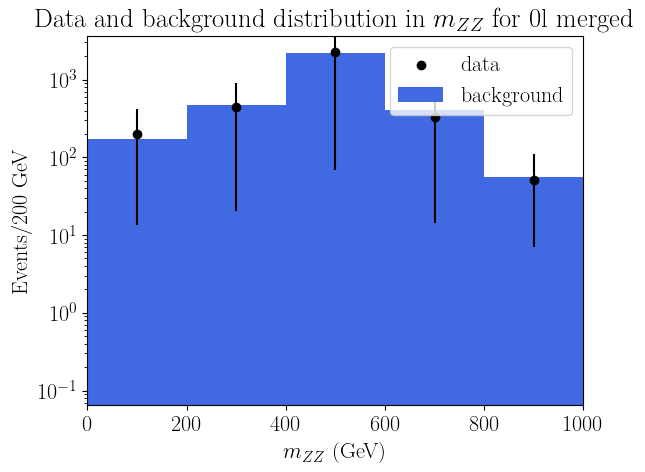

In [247]:
plt.bar(mZZ_bins_fat[:-1], background_fat, width=np.diff(mZZ_bins_fat), align='edge', alpha=1, color='royalblue',label='background')
plt.scatter(mZZ_bin_center_fat, data, color='black', label='data')
plt.xlim(0,1000)
#plt.ylim(0,5)
plt.yscale("log")
plt.errorbar(mZZ_bin_center_fat, data_fat, [unc_lower_fat, unc_upper_fat], color='black', alpha=1,fmt='none')
plt.xlabel('$m_{ZZ}$ (GeV) ')
plt.ylabel(r'Events/200 GeV')
plt.title("Data and background distribution in $m_{ZZ}$ for 0l merged")
plt.legend()

In [248]:
(data_fat*np.diff(mZZ_bins_fat)).sum()

657485.8550406066

## Signal events in the right bins, normalised distribution 

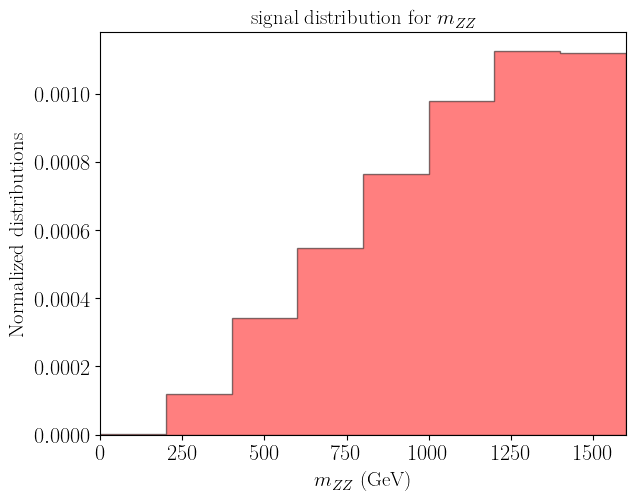

In [249]:
# histogram for NP signal (n = number of events per bin)
# density=True gives bin's raw count divided by the total number of counts and the bin width, i.e. density = counts / (sum(counts) * np.diff(bins))
n_signal_fat, bins, _ = plt.hist(mZZ_fat,bins=mZZ_bins_fat,range=(0,1600),label='non-linear axion', alpha=0.5,density=True,color = "red", ec="k",histtype='stepfilled',log=False)
plt.xlim(0, 1600)
#plt.yscale("log")
plt.tight_layout()
plt.title(r'signal distribution for $m_{ZZ}$ ',fontsize=15)
plt.xlabel(r'$m_{ZZ}$ (GeV)',fontsize=15)
plt.ylabel(r'Normalized distributions',fontsize=15)
#plt.savefig("mHHdist.pdf")
plt.show()

In [250]:
(n_signal_fat*np.diff(mZZ_bins_fat)).sum()

1.0

## Compare signal with data and background

In [251]:
# BR: factor of the branching ratios due to generating Z-> nu nu instead of Z-> jj
BR_Znunu = 0.2
BR_Zll = 0.101
BR_Zjj = 0.699

BR = BR_Zjj/BR_Zll

In [252]:
# rescale the MG5 signal events to compare with the data: N_events = n_signal * lumi * sigma * eps * BR
# eps = efficiency to the bin selection = number of events that fall in the ATLAS bins/ number of all events
# sigma in lhe file: total cross section including BR sigma in pb


# careful! the lumi is given in fb^-1 but the cross section from MadGraphin pb, which explains the additional factor of 1000.
lumi = 140

N_events_fat = n_signal_fat*lumi*sigma*1000*eps_fat*BR

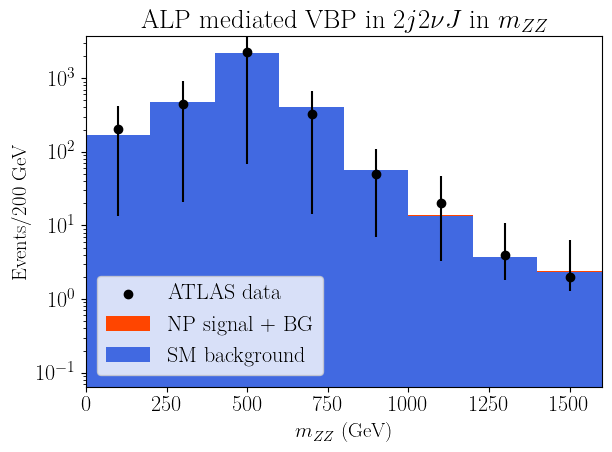

In [256]:
plt.bar(mZZ_bins_fat[:-1], background+N_events_fat, width=np.diff(mZZ_bins_fat), align='edge', alpha=1, color='orangered', label='NP signal + BG')
plt.bar(mZZ_bins_fat[:-1], background, width=np.diff(mZZ_bins_fat), align='edge', alpha=1, color='royalblue',label='SM background')
plt.xlim(0, 1600)
#plt.ylim(0,10000)
plt.yscale("log")
plt.xlabel('$m_{ZZ}$ (GeV)',fontsize=15)
plt.ylabel(r'Events/200 GeV', fontsize=15)
plt.errorbar(mZZ_bin_center_fat, data_fat, yerr=[unc_lower_fat, unc_upper_fat], color='black', alpha=1,fmt='none')
plt.scatter(mZZ_bin_center_fat, data_fat, color='black', label='ATLAS data')
plt.legend(loc=3)
plt.title(r" ALP mediated VBP in $2j2\nu J$ in $m_{ZZ}$")
plt.tight_layout()
plt.savefig("/Users/esser/Documents/PROJECTS/ALPsPheno/ALP GLOBAL/github/ALP_GLOBAL/Figures/ZZjj0l_merged.pdf")
plt.show()

### Output data to Mathematica

In [257]:
# calculate the mean error from the upper and lower end
data_unc_fat = (unc_upper_fat-unc_lower_fat)/2

In [262]:
# data
Mathematica_data = "{" + ",".join([f"{x:.4e}".replace('e', '*10^') for x in data_fat]) + "}" + ";"
print(Mathematica_data)

{2.0112*10^+02,4.4189*10^+02,2.2370*10^+03,3.3084*10^+02,5.0509*10^+01,2.0114*10^+01,3.9538*10^+00,1.9895*10^+00};


In [259]:
# data unc
Mathematica_data_unc = "{" + ",".join([f"{x:.4e}".replace('e', '*10^') for x in data_unc_fat]) + "}" ";"
print(Mathematica_data_unc)

{1.3656*10^+01,2.2062*10^+01,6.2972*10^+01,1.5672*10^+01,7.6171*10^+00,5.3541*10^+00,2.3509*10^+00,1.8562*10^+00};


In [260]:
# background
Mathematica_background = "{" + ",".join([f"{x:.4e}".replace('e', '*10^') for x in background_fat]) + "}" ";"
print(Mathematica_background)

{1.7036*10^+02,4.6709*10^+02,2.1720*10^+03,4.0662*10^+02,5.6577*10^+01,1.3629*10^+01,3.6755*10^+00,2.3610*10^+00};


In [261]:
#signal
N_signal_fat = n_signal_fat * lumi * sigma * 1000 * eps_fat * BR
Mathematica_signal = "{" + ",".join([f"{x:.4e}".replace('e', '*10^') for x in N_signal_fat]) + "}" ";"
print(Mathematica_signal)

{1.4858*10^-05,6.4185*10^-03,1.8587*10^-02,2.9641*10^-02,4.1557*10^-02,5.3072*10^-02,6.1080*10^-02,6.0768*10^-02};
